# Singular Value Decomposition with a Dog Image

Using a single photo of two dogs to build intuition for SVD.

- An image is just a matrix of pixel intensities.
- We factor it: $X = U \Sigma V^\dagger$ where $V^\dagger = V^T$ when $V$ is real.
- Truncating that factorization gives us low-rank approximation and compression.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

plt.rcParams["figure.figsize"] = [12, 6]
plt.rcParams["font.size"] = 13

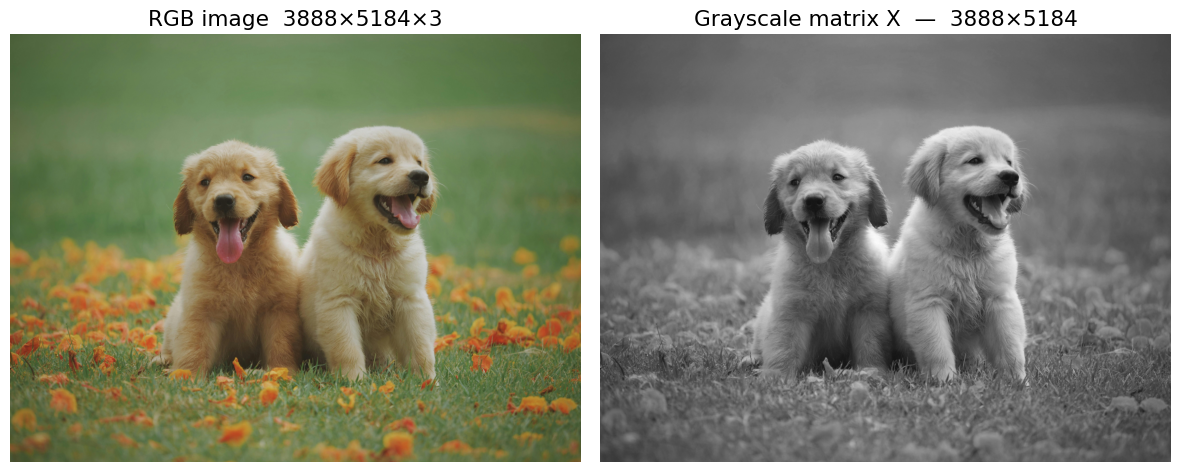

X has 20,155,392 pixel values
Min: 16   Max: 224


In [2]:
A = imread("dogs.jpg")
X = np.mean(A, axis=-1).astype(float)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(A)
axes[0].axis("off")
axes[0].set_title(f"RGB image  {A.shape[0]}×{A.shape[1]}×3")

axes[1].imshow(X, cmap="gray")
axes[1].axis("off")
axes[1].set_title(f"Grayscale matrix X  —  {X.shape[0]}×{X.shape[1]}")

plt.tight_layout()
plt.show()

print(f"X has {X.shape[0]*X.shape[1]:,} pixel values")
print(f"Min: {X.min():.0f}   Max: {X.max():.0f}")

## The image is just a matrix

The grayscale image above is a matrix $X \in \mathbb{R}^{N \times M}$ where $n$ is the number
of rows (pixel height) and $m$ is the number of columns (pixel width).
Every entry $X_{ij}$ is a number between 0 and 255.

## Decomposition

For *any* matrix $X \in \mathbb{R}^{N \times M}$, the SVD is

$$X = U \Sigma V^\dagger$$

- $U \in \mathbb{R}^{N \times N}$ — columns are **left singular vectors**, orthonormal, encode *row-space* patterns.
- $\Sigma \in \mathbb{R}^{N \times M}$ — diagonal, entries $\sigma_1 \ge \sigma_2 \ge \cdots \ge 0$ called **singular values**.
- $V \in \mathbb{R}^{M \times M}$ — columns are **right singular vectors**, orthonormal, encode *column-space* patterns.

`full_matrices=False` gives the **economy SVD**. For a tall matrix it drops the zero rows of $\Sigma$
and the corresponding columns of $U$, saving memory without losing anything.

In [3]:
U, S, VT = np.linalg.svd(X, full_matrices=False)

print("U shape :", U.shape)
print("S shape :", S.shape, "  <-- these are the σ_k values")
print("VT shape:", VT.shape)
print("\nTop 10 singular values:")
print(np.round(S[:10]).astype(int))

X_reconstructed = U @ np.diag(S) @ VT
print(f"\nFull reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}  (should be ~0)")

U shape : (3888, 3888)
S shape : (3888,)   <-- these are the σ_k values
VT shape: (3888, 5184)

Top 10 singular values:
[482743  51554  34158  28676  21091  20710  17879  14769  13840  11735]

Full reconstruction error: 1.12e-08  (should be ~0)


## The singular value spectrum

The singular values $\sigma_1 \ge \sigma_2 \ge \cdots$ tell you how much each mode contributes.

Two useful plots:

1. **Log plot of $\sigma_k$**: shows how fast they decay.
2. **Cumulative sum** $\displaystyle\frac{\sum_{k=1}^r \sigma_k}{\sum_k \sigma_k}$: shows what fraction of the total
   signal is captured by the first $r$ modes.

For natural images, the decay is very fast. That is the key fact that makes compression possible.

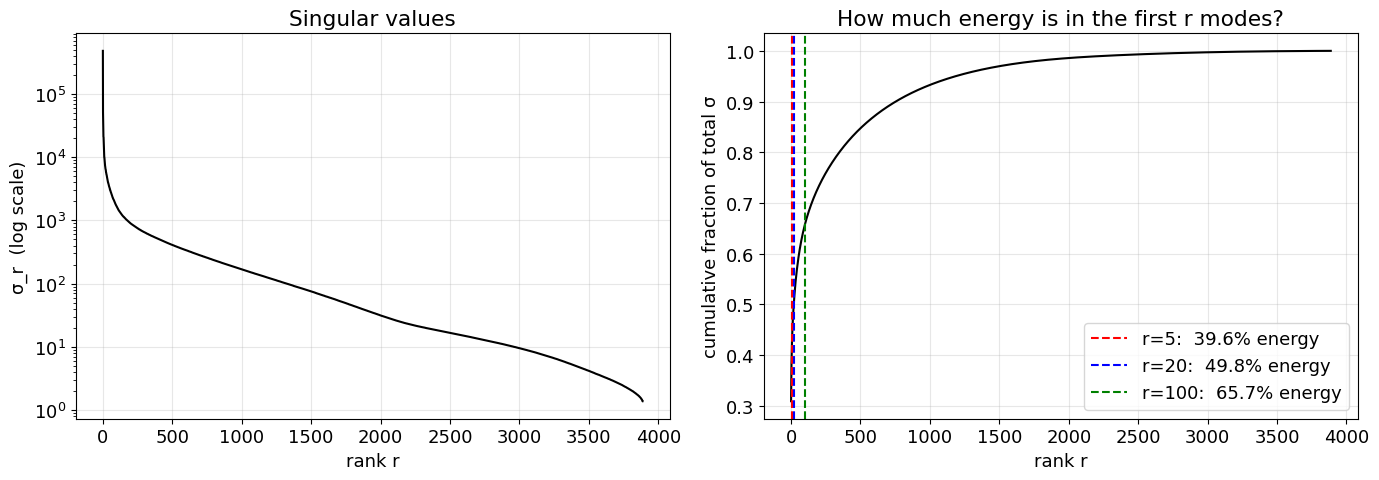

In [4]:
n, m = X.shape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(S, "k")
axes[0].set_xlabel("rank r")
axes[0].set_ylabel("σ_r  (log scale)")
axes[0].set_title("Singular values")
axes[0].grid(True, alpha=0.3)

cum = np.cumsum(S) / np.sum(S)
axes[1].plot(cum, "k")
for r, color in [(5, "red"), (20, "blue"), (100, "green")]:
    axes[1].axvline(r, color=color, linestyle="--",
                    label=f"r={r}:  {cum[r-1]*100:.1f}% energy")
axes[1].set_xlabel("rank r")
axes[1].set_ylabel("cumulative fraction of total σ")
axes[1].set_title("How much energy is in the first r modes?")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Truncated SVD: low-rank approximation

Because $\Sigma$ is diagonal we can expand the SVD as a sum of **rank-1 matrices**
(called the *dyadic summation*):

$$X = \sum_{k=1}^{M} \sigma_k \, u_k v_k^T$$

Each term $\sigma_k u_k v_k^T$ is rank-1: it is an outer product of the $k$-th
left singular vector $u_k$ and right singular vector $v_k$, scaled by $\sigma_k$.

Since $\sigma_1 \ge \sigma_2 \ge \cdots$, the first terms carry the most information.
Keeping only the first $r$ terms gives the **rank-$r$ truncated SVD**:

$$\tilde{X}_r = \sum_{k=1}^{r} \sigma_k \, u_k v_k^T = \tilde{U}\,\tilde{\Sigma}\,\tilde{V}^T$$

**Eckart–Young theorem:** $\tilde{X}_r$ is the *best possible* rank-$r$ approximation to $X$
in the Frobenius norm. No other rank-$r$ matrix can do better.

The Frobenius error is exactly:

$$\|X - \tilde{X}_r\|_F^2 = \sum_{k=r+1}^{M} \sigma_k^2$$

so the error is precisely the energy in the singular values we *threw away*.

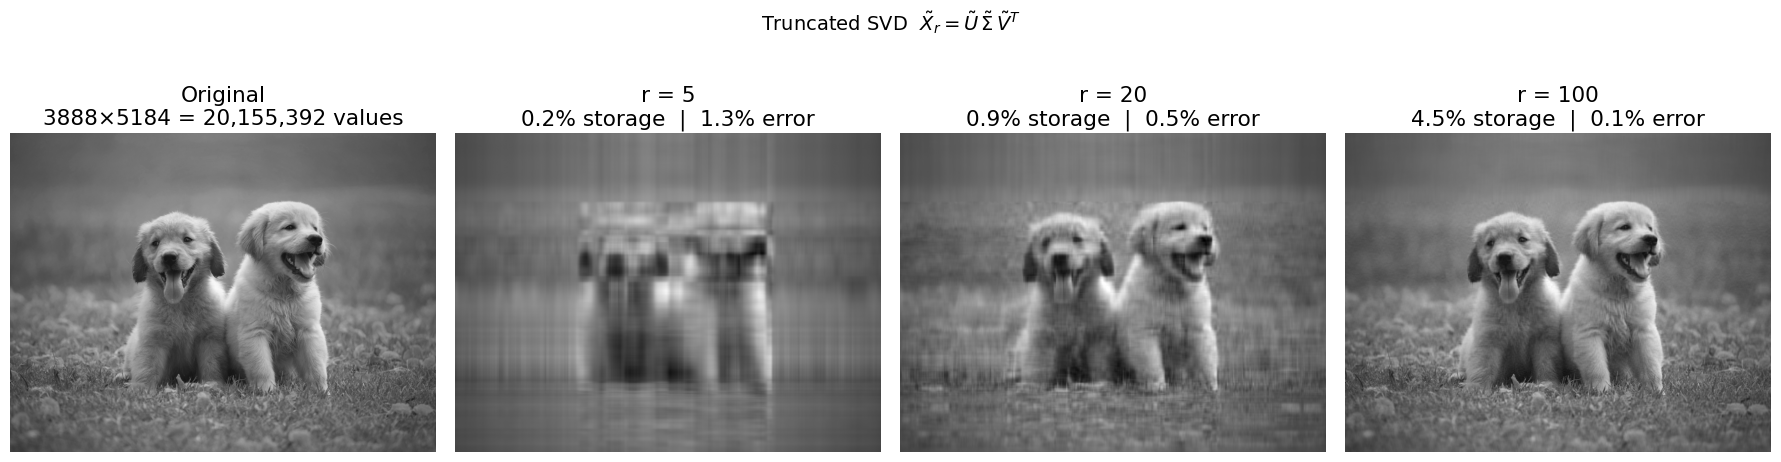

In [5]:
ranks = [5, 20, 100]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(X, cmap="gray")
axes[0].axis("off")
axes[0].set_title(f"Original\n{n}×{m} = {n*m:,} values")

for ax, r in zip(axes[1:], ranks):
    Xr = U[:, :r] @ np.diag(S[:r]) @ VT[:r, :]
    storage = r * (n + m + 1) / (n * m) * 100
    err = np.sum(S[r:]**2) / np.sum(S**2) * 100
    ax.imshow(Xr, cmap="gray", vmin=X.min(), vmax=X.max())
    ax.axis("off")
    ax.set_title(f"r = {r}\n{storage:.1f}% storage  |  {err:.1f}% error")

plt.suptitle("Truncated SVD  $\\tilde{X}_r = \\tilde{U}\\,\\tilde{\\Sigma}\\,\\tilde{V}^T$",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## The rank-1 building blocks

Let's look at individual terms $\sigma_k u_k v_k^T$ directly.

- $u_k \in \mathbb{R}^N$ is a column vector and it encodes a **vertical pattern** across the rows of the image.
- $v_k \in \mathbb{R}^M$ is a column vector and it encodes a **horizontal pattern** across the columns.
- Their outer product $u_k v_k^T$ is a full $N \times M$ rank-1 image, scaled by $\sigma_k$.

The first few modes capture the coarsest structure with large uniform regions and
dominant orientations. Each subsequent mode picks up progressively finer detail.
By mode 4 or 5 it already looks like structured noise, which is why we can discard those terms
and lose very little of the actual image content.

The sum $\tilde{X}_r = \sum_{k=1}^r \sigma_k u_k v_k^T$ literally **adds these images together**
one layer at a time, rebuilding the photo from scratch.

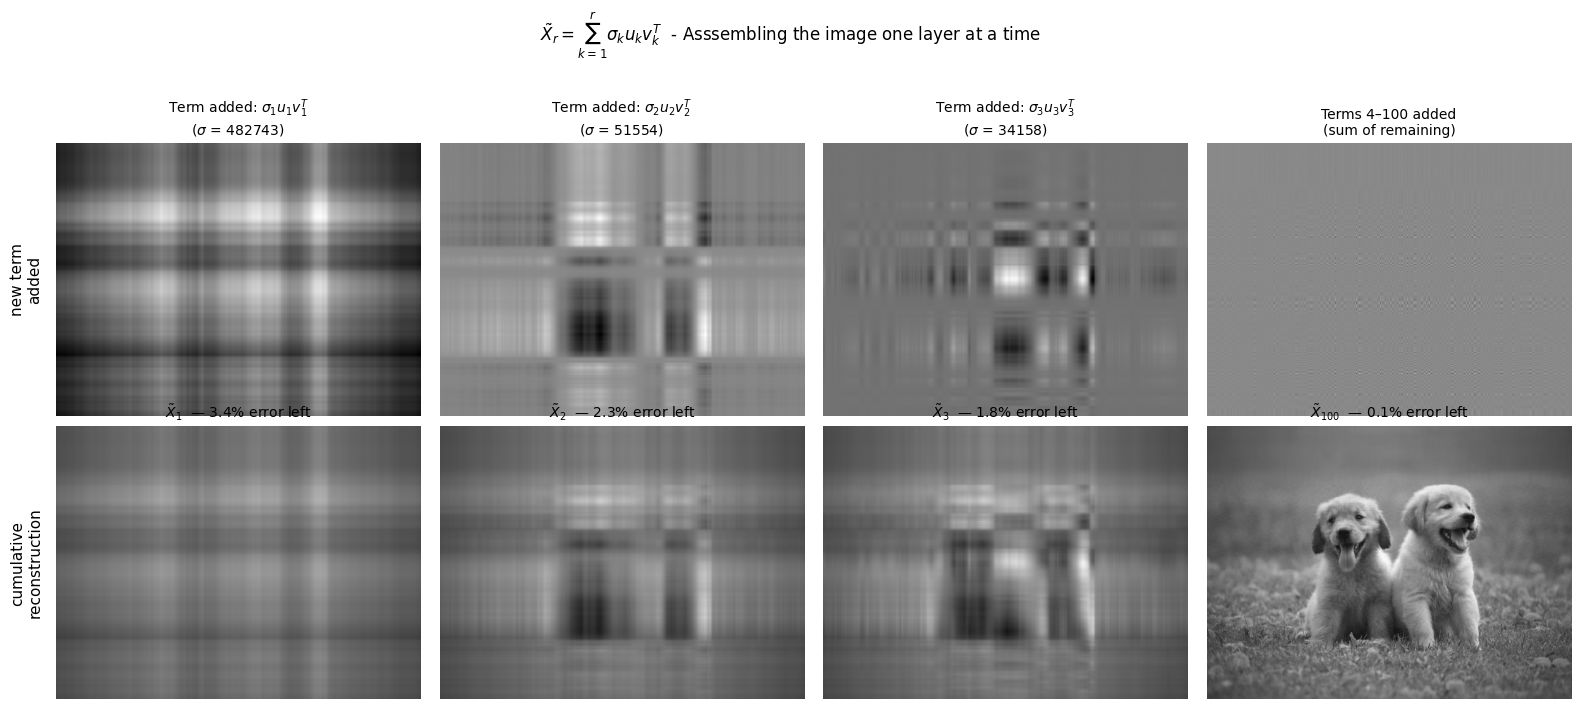

In [6]:
checkpoints = [1, 2, 3, 100]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for col, r in enumerate(checkpoints):
    # cumulative sum of rank-1 terms up to mode r
    X_cumulative = U[:, :r] @ np.diag(S[:r]) @ VT[:r, :]

    # top row: the new rank-1 term being added at this step
    rank1 = S[r-1] * np.outer(U[:, r-1], VT[r-1, :])
    axes[0, col].imshow(rank1, cmap="gray")
    axes[0, col].axis("off")
    if r <= 3:
        axes[0, col].set_title(f"Term added: $\\sigma_{{{r}}} u_{{{r}}} v_{{{r}}}^T$\n($\\sigma$ = {S[r-1]:.0f})", fontsize=10)
    else:
        axes[0, col].set_title(f"Terms {checkpoints[col-1]+1}–{r} added\n(sum of remaining)", fontsize=10)

    # bottom row: cumulative reconstruction so far
    axes[1, col].imshow(X_cumulative, cmap="gray", vmin=X.min(), vmax=X.max())
    axes[1, col].axis("off")
    err = np.sum(S[r:]**2) / np.sum(S**2) * 100
    axes[1, col].set_title(f"$\\tilde{{X}}_{{{r}}}$  — {err:.1f}% error left", fontsize=10)

# label the two rows clearly
axes[0, 0].set_ylabel("new term\nadded", fontsize=11, labelpad=10)
axes[1, 0].set_ylabel("cumulative\nreconstruction", fontsize=11, labelpad=10)
for ax in [axes[0,0], axes[1,0]]:
    ax.axis("on")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle(
    "$\\tilde{X}_r = \\sum_{k=1}^{r} \\sigma_k u_k v_k^T$  - Asssembling the image one layer at a time",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()